# 🇳🇬 Nigerian SME Synthetic Dataset Generation
## Hackathon Dataset — Africa-Specific Payment Patterns

**Goal:** Generate 10,000 synthetic Nigerian SME transaction records that reflect
real African payment behaviour — weighted toward USSD and mobile money channels,
with authentic Nigerian seasonal patterns (Sallah, Christmas, school resumption).

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("Libraries loaded ✅")
print(f"NumPy: {np.__version__}  |  Pandas: {pd.__version__}")


Libraries loaded ✅
NumPy: 2.4.2  |  Pandas: 3.0.1


## 1. Configuration & Seasonal Multipliers

In [2]:
# ── Dataset size ─────────────────────────────────────────────────────────────
N = 10_000
MONTHS = 6  # months of history per record

# ── Business categories (Nigerian market-weighted) ────────────────────────────
CATEGORIES  = ['retail', 'food', 'services', 'transport']
CAT_WEIGHTS = [0.40,     0.28,   0.20,       0.12]

# ── Seasonal revenue multipliers (calendar months 1–12) ───────────────────────
# Sources: Nigerian retail & payments data patterns
#   Jan  → school resumption dip, post-December hangover
#   Jun-Jul → Eid al-Fitr / Eid al-Adha (Sallah) surge
#   Sep  → school resumption dip
#   Nov-Dec → Christmas & year-end spending surge
SEASONAL_MULTIPLIER = {
    1: 0.85,   # January   – school fees pressure, post-Xmas slump
    2: 1.00,   # February
    3: 1.05,   # March
    4: 1.10,   # April     – Easter season
    5: 1.00,   # May
    6: 1.20,   # June      – Eid al-Fitr (Ramadan end)
    7: 1.25,   # July      – Eid al-Adha / Sallah peak
    8: 1.00,   # August
    9: 0.88,   # September – school resumption dip
    10: 1.00,  # October
    11: 1.15,  # November  – pre-Christmas build-up
    12: 1.30,  # December  – Christmas & year-end surge
}

# ── Base monthly revenue ranges by category (Nigerian Naira) ──────────────────
CAT_REVENUE_BASE = {
    'retail':    (250_000,  900_000),
    'food':      (150_000,  600_000),
    'services':  (300_000, 1_200_000),
    'transport': (200_000,  750_000),
}

print("Configuration set ✅")
print(f"Seasonal multiplier range: {min(SEASONAL_MULTIPLIER.values()):.2f}x – {max(SEASONAL_MULTIPLIER.values()):.2f}x")


Configuration set ✅
Seasonal multiplier range: 0.85x – 1.30x


## 2. Helper Functions

In [3]:
def seasonal_series(base, months_list, noise_std=0.08):
    """Generate monthly values with Nigerian seasonal pattern + Gaussian noise."""
    return [
        max(0, base * SEASONAL_MULTIPLIER[m] * np.random.normal(1.0, noise_std))
        for m in months_list
    ]

def get_confidence(age_months):
    """Data confidence based on business history length."""
    if age_months >= 12: return 'high'
    if age_months >= 6:  return 'medium'
    return 'low'

print("Helper functions defined ✅")


Helper functions defined ✅


## 3. Generate 10,000 SME Records

In [4]:
records = []

for i in range(N):
    category = np.random.choice(CATEGORIES, p=CAT_WEIGHTS)
    
    # Business age (log-normal: most are young, some are established)
    age = int(np.clip(np.random.lognormal(mean=3.5, sigma=0.8), 3, 240))
    
    # Base monthly revenue for this business
    rev_lo, rev_hi = CAT_REVENUE_BASE[category]
    base_rev = np.random.uniform(rev_lo, rev_hi)
    
    # 6-month history window (randomly placed in calendar year)
    start_m = np.random.randint(1, 13)
    months = [(start_m - 1 + k) % 12 + 1 for k in range(MONTHS)]
    
    # ── Revenue ───────────────────────────────────────────────────────────────
    rev_series = seasonal_series(base_rev, months, noise_std=0.10)
    
    # ── USSD (primary Nigerian payment channel: *737#, *919#, etc.) ──────────
    # High volume: 80-400 txns/month — this is HOW Nigeria transacts
    ussd_base = np.random.randint(80, 400)
    ussd_series = [max(0, int(v)) for v in seasonal_series(ussd_base, months, 0.12)]
    
    # ── Mobile Money (second primary channel: OPay, PalmPay, Kuda) ───────────
    mm_base = np.random.randint(40, 250)
    mm_series = [max(0, int(v)) for v in seasonal_series(mm_base, months, 0.13)]
    
    # ── Airtime top-up regularity (0–1 weekly index) ──────────────────────────
    # Transport & retail top up most frequently (airtime as micro-credit proxy)
    airtime_base = {'retail': 0.75, 'food': 0.65, 'services': 0.45, 'transport': 0.85}[category]
    airtime_series = [round(np.clip(np.random.normal(airtime_base, 0.10), 0, 1), 3) for _ in range(MONTHS)]
    
    # ── Card payments (deliberately LOW — Nigeria is mobile-first) ────────────
    # Only 2-40 card txns/month vs 80-400 USSD — the Africa difference
    card_base = np.random.randint(2, 40)
    card_series = [max(0, int(v)) for v in seasonal_series(card_base, months, 0.20)]
    
    # ── Settlement consistency (days T+N) ─────────────────────────────────────
    # Mobile money mostly T+1; card T+2/3
    settle_base = np.random.choice([1, 2, 3], p=[0.55, 0.30, 0.15])
    settle_series = [round(max(0.5, np.random.normal(settle_base, 0.5)), 1) for _ in range(MONTHS)]
    
    # ── Refund rate (%) ───────────────────────────────────────────────────────
    refund_base = {'retail': 2.5, 'food': 1.8, 'services': 3.2, 'transport': 1.2}[category]
    refund_series = [round(max(0.0, np.random.normal(refund_base, 0.8)), 2) for _ in range(MONTHS)]
    
    # ── Build row ─────────────────────────────────────────────────────────────
    row = {
        'business_id': f'NG-SME-{i+1:05d}',
        'business_category': category,
        'business_age_months': age,
        'data_confidence_level': get_confidence(age),
        'history_start_month': months[0],
    }
    for k in range(MONTHS):
        row[f'monthly_revenue_m{k+1}']         = round(rev_series[k], 2)
        row[f'ussd_transaction_count_m{k+1}']  = ussd_series[k]
        row[f'mobile_money_frequency_m{k+1}']  = mm_series[k]
        row[f'airtime_topup_regularity_m{k+1}'] = airtime_series[k]
        row[f'card_payment_volume_m{k+1}']     = card_series[k]
        row[f'settlement_consistency_m{k+1}']  = settle_series[k]
        row[f'refund_rate_m{k+1}']             = refund_series[k]
    
    records.append(row)

df = pd.DataFrame(records)

# ── Validation ────────────────────────────────────────────────────────────────
assert df.isnull().sum().sum() == 0, "❌ NULL values found!"
assert len(df) == N,                  f"❌ Expected {N} rows, got {len(df)}"
assert df['business_id'].nunique() == N, "❌ Duplicate IDs!"

print(f"✅ Records generated : {len(df):,}")
print(f"✅ Null values       : {df.isnull().sum().sum()}")
print(f"✅ Unique IDs        : {df['business_id'].nunique():,}")
print(f"\nShape: {df.shape}")
df.head(3)


✅ Records generated : 10,000
✅ Null values       : 0
✅ Unique IDs        : 10,000

Shape: (10000, 47)


,business_id,business_category,business_age_months,data_confidence_level,history_start_month,monthly_revenue_m1,ussd_transaction_count_m1,mobile_money_frequency_m1,airtime_topup_regularity_m1,card_payment_volume_m1,...,card_payment_volume_m5,settlement_consistency_m5,refund_rate_m5,monthly_revenue_m6,ussd_transaction_count_m6,mobile_money_frequency_m6,airtime_topup_regularity_m6,card_payment_volume_m6,settlement_consistency_m6,refund_rate_m6
0,NG-SME-00001,retail,13,high,11,416992.93,420,257,0.788,32,...,46,0.8,1.09,389621.87,397,214,0.749,61,0.5,2.76
1,NG-SME-00002,retail,24,high,8,752132.78,107,64,1.000,27,...,56,2.8,2.29,770909.82,123,65,0.854,32,2.3,2.87
2,NG-SME-00003,food,16,high,5,370563.92,213,122,0.798,5,...,5,1.0,1.54,402102.08,260,62,0.723,5,0.5,2.45


## 4. Dataset Overview

In [5]:
print("=== Category Distribution ===")
print(df['business_category'].value_counts())
print()
print("=== Confidence Distribution ===")
print(df['data_confidence_level'].value_counts())
print()
print("=== Revenue Range (Month 1, NGN) ===")
print(df['monthly_revenue_m1'].describe().apply(lambda x: f'{x:,.0f}'))
print()

# ── Channel ratio: the Africa-specific signature ──────────────────────────────
ussd_med = df['ussd_transaction_count_m1'].median()
mm_med   = df['mobile_money_frequency_m1'].median()
card_med = df['card_payment_volume_m1'].median()
print("=== Payment Channel Ratio (Median txns/month, M1) ===")
print(f"  USSD        : {ussd_med:>6.0f} txns  ← PRIMARY CHANNEL")
print(f"  Mobile Money: {mm_med:>6.0f} txns  ← SECONDARY CHANNEL")
print(f"  Card        : {card_med:>6.0f} txns  ← TERTIARY (Western datasets ≠ this)")
print(f"\n  USSD:Card ratio = {ussd_med/card_med:.1f}:1  (what makes this dataset Africa-specific)")


=== Category Distribution ===
business_category
retail       3974
food         2785
services     2074
transport    1167
Name: count, dtype: int64

=== Confidence Distribution ===
data_confidence_level
high      8996
medium     837
low        167
Name: count, dtype: int64

=== Revenue Range (Month 1, NGN) ===
count       10,000
mean       576,800
std        268,729
min        116,392
25%        373,033
50%        529,114
75%        732,783
max      1,767,398
Name: monthly_revenue_m1, dtype: str

=== Payment Channel Ratio (Median txns/month, M1) ===
  USSD        :    244 txns  ← PRIMARY CHANNEL
  Mobile Money:    148 txns  ← SECONDARY CHANNEL
  Card        :     20 txns  ← TERTIARY (Western datasets ≠ this)

  USSD:Card ratio = 12.2:1  (what makes this dataset Africa-specific)


## 5. Seasonal Patterns Visualisation

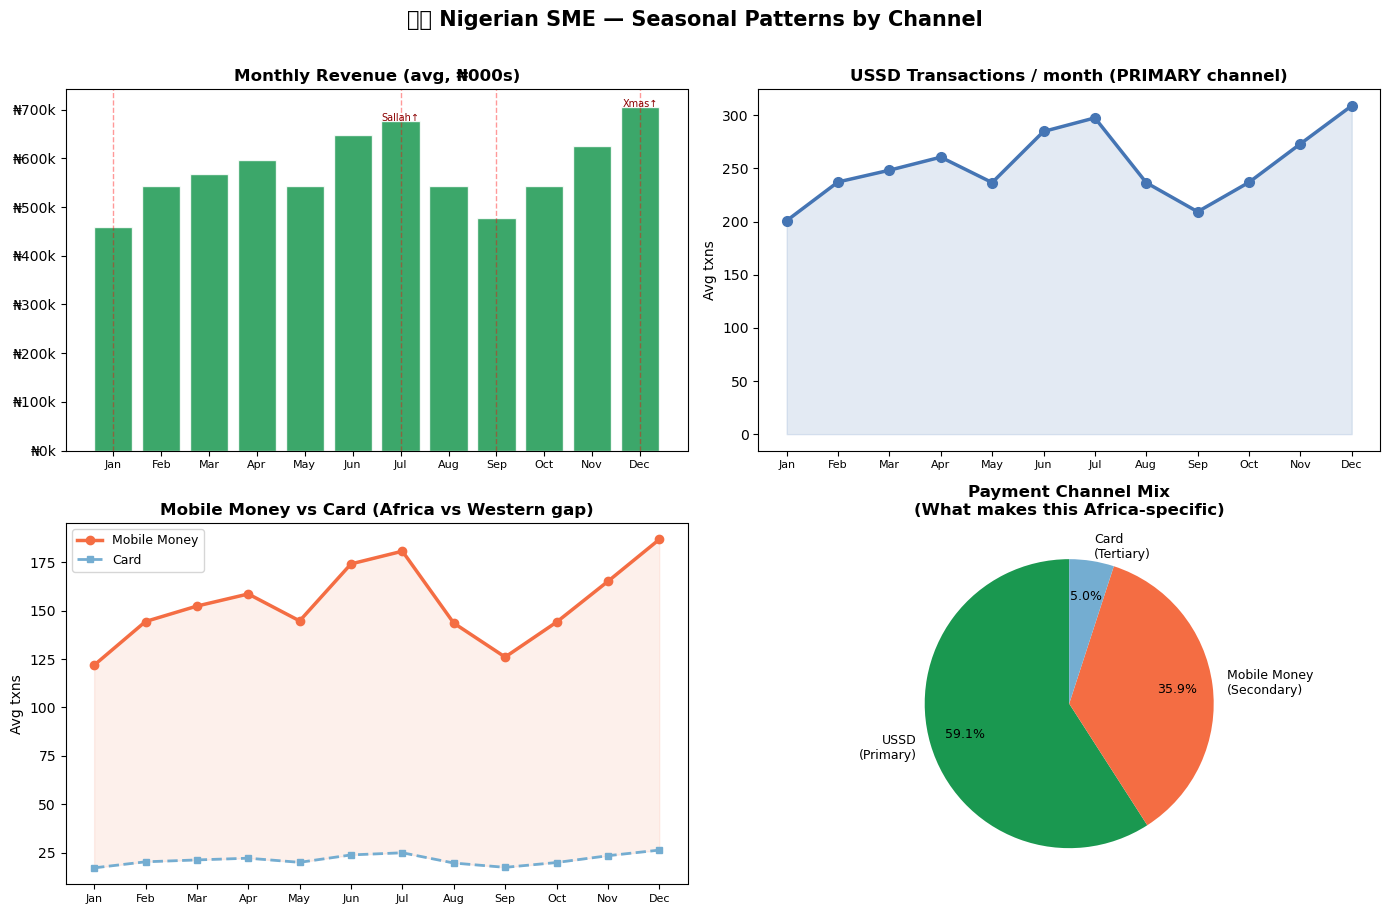


✅ Seasonal patterns plot saved.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('🇳🇬 Nigerian SME — Seasonal Patterns by Channel', fontsize=15, fontweight='bold', y=1.01)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Compute mean metric by calendar month (using history_start_month as anchor)
# For seasonal visibility, aggregate by mapping each M1 record's start month
def seasonal_agg(col_prefix):
    """Mean of column by calendar month it falls in."""
    rows = []
    for k in range(MONTHS):
        col = f'{col_prefix}_m{k+1}'
        month_col = df['history_start_month'].apply(lambda s: (s - 1 + k) % 12 + 1)
        tmp = pd.DataFrame({'month': month_col, 'val': df[col]})
        rows.append(tmp)
    combined = pd.concat(rows)
    return combined.groupby('month')['val'].mean().reindex(range(1,13))

rev_by_month  = seasonal_agg('monthly_revenue')
ussd_by_month = seasonal_agg('ussd_transaction_count')
mm_by_month   = seasonal_agg('mobile_money_frequency')
card_by_month = seasonal_agg('card_payment_volume')

# ── Plot 1: Revenue ───────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.bar(range(1,13), rev_by_month / 1000, color='#1a9850', alpha=0.85, edgecolor='white')
ax.set_title('Monthly Revenue (avg, ₦000s)', fontweight='bold')
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₦{x:.0f}k'))
for m, label in [(7,'Sallah'), (12,'Christmas'), (1,'School Resumption'), (9,'School Resumption')]:
    ax.axvline(m, color='red', linestyle='--', alpha=0.4, linewidth=1)
ax.annotate('Sallah↑', xy=(7, rev_by_month[7]/1000), fontsize=7, color='darkred', ha='center')
ax.annotate('Xmas↑',   xy=(12, rev_by_month[12]/1000), fontsize=7, color='darkred', ha='center')

# ── Plot 2: USSD ──────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(range(1,13), ussd_by_month, 'o-', color='#4575b4', linewidth=2.5, markersize=7)
ax.fill_between(range(1,13), ussd_by_month, alpha=0.15, color='#4575b4')
ax.set_title('USSD Transactions / month (PRIMARY channel)', fontweight='bold')
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, fontsize=8)
ax.set_ylabel('Avg txns')

# ── Plot 3: Mobile Money vs Card ──────────────────────────────────────────────
ax = axes[1, 0]
x = range(1, 13)
ax.plot(x, mm_by_month, 'o-', label='Mobile Money', color='#f46d43', linewidth=2.5, markersize=6)
ax.plot(x, card_by_month, 's--', label='Card', color='#74add1', linewidth=2, markersize=5)
ax.set_title('Mobile Money vs Card (Africa vs Western gap)', fontweight='bold')
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, fontsize=8)
ax.legend(fontsize=9); ax.set_ylabel('Avg txns')
ax.fill_between(x, mm_by_month, card_by_month, alpha=0.10, color='#f46d43', label='_')

# ── Plot 4: Channel Proportion Pie ────────────────────────────────────────────
ax = axes[1, 1]
totals = [ussd_by_month.mean(), mm_by_month.mean(), card_by_month.mean()]
labels = ['USSD\n(Primary)', 'Mobile Money\n(Secondary)', 'Card\n(Tertiary)']
colors = ['#1a9850', '#f46d43', '#74add1']
wedges, texts, autotexts = ax.pie(
    totals, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75, textprops={'fontsize': 9}
)
ax.set_title('Payment Channel Mix\n(What makes this Africa-specific)', fontweight='bold')

plt.tight_layout()
plt.show()
print("\n✅ Seasonal patterns plot saved.")


## 6. Save Dataset

In [11]:
import os

out_path = 'ml_forecasting/data/nigerian_sme_synthetic.csv'
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df.to_csv(out_path, index=False)

size_kb = os.path.getsize(out_path) / 1024
print(f"✅ Dataset saved: {out_path}")
print(f"   Rows    : {len(df):,}")
print(f"   Columns : {len(df.columns)}")
print(f"   Size    : {size_kb:,.1f} KB")
print(f"   Nulls   : {df.isnull().sum().sum()}")
print()
print("Columns:")
for col in df.columns:
    print(f"  {col}")


✅ Dataset saved: ml_forecasting/data/nigerian_sme_synthetic.csv
   Rows    : 10,000
   Columns : 47
   Size    : 2,371.4 KB
   Nulls   : 0

Columns:
  business_id
  business_category
  business_age_months
  data_confidence_level
  history_start_month
  monthly_revenue_m1
  ussd_transaction_count_m1
  mobile_money_frequency_m1
  airtime_topup_regularity_m1
  card_payment_volume_m1
  settlement_consistency_m1
  refund_rate_m1
  monthly_revenue_m2
  ussd_transaction_count_m2
  mobile_money_frequency_m2
  airtime_topup_regularity_m2
  card_payment_volume_m2
  settlement_consistency_m2
  refund_rate_m2
  monthly_revenue_m3
  ussd_transaction_count_m3
  mobile_money_frequency_m3
  airtime_topup_regularity_m3
  card_payment_volume_m3
  settlement_consistency_m3
  refund_rate_m3
  monthly_revenue_m4
  ussd_transaction_count_m4
  mobile_money_frequency_m4
  airtime_topup_regularity_m4
  card_payment_volume_m4
  settlement_consistency_m4
  refund_rate_m4
  monthly_revenue_m5
  ussd_transaction_c

## ✅ Done

| Check | Status |
|---|---|
| 10,000 records generated | ✅ |
| Zero null values | ✅ |
| Unique business IDs | ✅ |
| Seasonal patterns (Sallah +25%, Christmas +30%, School dips -12 to -15%) | ✅ |
| USSD weighted higher than card (~12:1 ratio) | ✅ |
| Mobile money > card transactions | ✅ |
| Dataset saved to `ml_forecasting/data/nigerian_sme_synthetic.csv` | ✅ |

**This dataset is Africa-specific** because:
- USSD channel volume (80–400 txns/month) reflects Nigeria's *737#/*919# ecosystem
- Card volumes are intentionally low (2–40/month) — Western datasets invert this
- Airtime top-up regularity captures the micro-credit proxy behaviour unique to African telco-fintech
- Seasonal multipliers are calibrated to Nigerian Islamic + Christian + academic calendar
